## 前期演習

- 前期の最終週に提出。

## 第1回

### 問1

このNotebookを編集して、文章や数式を書いてみてください。

<br/>

**参考例**：  
Notebokファイル(**.ipynb)では、Pythonコードを実行するだけでなく、Markdown記法を使って文章や数式 ( $y = f(x)$ など) を記述することが出来ます。  
記述方法は以下のwebsiteを参考にしたり、ネットで調べたりしてください。
- Markdown記法：https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax
- 数式：https://docs.github.com/en/get-started/writing-on-github/working-with-advanced-formatting/writing-mathematical-expressions

- $y = f(x)$ <br><br>
- $\sqrt{3x-1}+(1+x)^2$

# 2次方程式の解の公式の導出

2次方程式  
$$
ax^2 + bx + c = 0
$$  
の解を求める。ただし、$a \neq 0$ とする。

## 両辺を $a$ で割り、$c/a$ を引く
$$
x^2 + \frac{b}{a}x = - \frac{c}{a}
$$

## 平方完成する
$$
\begin{split}
(x + \frac{b}{2a})^2 &= -\frac{c}{a} + \frac{b^2}{4a^2}  \\
&= \frac{-4ac + b^2}{4a^2} = \frac{b^2 - 4ac}{4a^2}
\end{split}
$$

## 両辺の平方根を取る
$$
x + \frac{b}{2a} = \pm \frac{\sqrt{b^2 - 4ac}}{2a}
$$

## 解を求める
$$
x = -\frac{b}{2a} \pm \frac{\sqrt{b^2 - 4ac}}{2a}
$$

**まとめ:**
  - 両辺を $a$ で割り、$c/a$ を引く
  - 平方完成する
  - 両辺の平方根を取る
  - 解を求める

### 問2

人工知能を使って、自分自身で実装してみたいことを述べなさい。既存のものでも、技術的にまだ不可能なものでも構いません。

A. 画像処理（物体検知）

### 問3

友達同士でピザパーティーを行います。何枚のホールピザを注文すべきか計算する関数 `pizza_needed` を作りなさい。  
ただし、以下の引数を備えること：
- `people`（参加人数）
- `slices_per_person`（1人あたり食べるスライス数。）
- `slices_per_pizza`（ホールピザ1枚あたりのスライス数。$8$ をデフォルトの数にすること。）

In [1]:
people = 5
slices_per_person = 3
slices_per_pizza = 8

def pizza_needed(people, slices_per_person, slices_per_pizza=8):
    total_slices_needed = people * slices_per_person
    pizzas_needed = total_slices_needed / slices_per_pizza
    if pizzas_needed % 1 != 0:
        pizzas_needed = int(pizzas_needed) + 1
    print(pizzas_needed)

pizza_needed(people, slices_per_person, slices_per_pizza)

2


### 問4

言葉をオウム返しするロボットを作る。次のようなクラスを作成しなさい：
- `__init__(self, name)`：ロボット自身の名前を設定。
- `repeat(self, message)`：ロボット自身の名前を言ったあとに、ロボットに投げかけた言葉 `message` を返す。
- `speak_count()` で、これまでに何回発言したか（`repeat()`が呼ばれた回数）を返す。

In [2]:
class Parrot:
    
    def __init__(self, name):
        self.name = name
        self.speak_counter = 0
    
    def repeat(self, message):
        print(message)
        self.speak_counter += 1
        
    def speak_count(self):
        print(self.speak_counter)
        
speedy = Parrot("Speedy")
speedy.repeat("Hello, world!")
speedy.repeat("How are you?")
speedy.speak_count()

Hello, world!
How are you?
2


## 第2回

### 問1

サイコロを $N$ 回投げた際の出目をシミュレーションし、そのサンプル平均を計算する。$N$ の値を $10, 100, 1000, 10000, 100000$ と変化させた場合に、それぞれのサンプル平均がどのように変化するかを確認しなさい。

【ヒント】
- `numpy.random.randint()` を使うと、サイコロを投げるシミュレーションが可能。
- `np.mean()` で平均値が計算できる。

In [57]:
import numpy as np

n = [10, 100, 1000, 10000, 100000]

for size in n:
    dice = np.random.randint(1, 7, size=size)
    print(f"{size:6}回サイコロを振った平均 : {np.mean(dice) :.2f}")

    10回サイコロを振った平均 : 3.30
   100回サイコロを振った平均 : 3.52
  1000回サイコロを振った平均 : 3.43
 10000回サイコロを振った平均 : 3.49
100000回サイコロを振った平均 : 3.51


### 問2

問1のシミュレーション結果から、試行回数 $N$ が増加するにつれてサンプル平均はどのような値に近づいていくかをプロットしながら考えなさい。

モンテカルロ法  
ベイズ統計

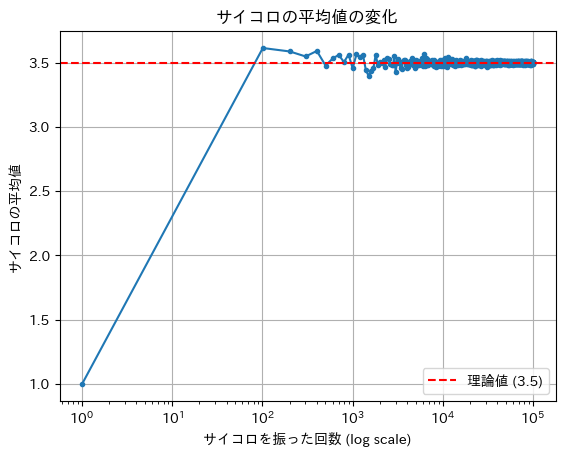

In [73]:
import matplotlib.pyplot as plt
import japanize_matplotlib

x = [i for i in range(1, 100000, 100)]
y = []

for size in range(1, 100000, 100):
    dice_rolls = np.random.randint(1, 7, size=size)
    y.append(np.mean(dice_rolls))

plt.plot(x, y, marker='.')
plt.xscale('log')
plt.xlabel('サイコロを振った回数 (log scale)')
plt.ylabel('サイコロの平均値')
plt.title('サイコロの平均値の変化')
plt.grid(True)

# モンテカルロ法による理論値との比較
expected_value = 3.5  # サイコロの理論的な平均値
plt.axhline(expected_value, color='red', linestyle='--', label='理論値 (3.5)')
plt.legend()
plt.show()

### 問3

以下の手順を行うコードを作成しなさい。
1.  区間 $[0, 1]$ の一様分布から、サイズ $n=30$ のサンプルを抽出する。
2.  抽出したサンプル平均を計算する。
3.  上記 1, 2 のステップを $M=10000$ 回繰り返し、得られた10000個のサンプル平均をNumPy配列に格納する。

【ヒント】
- 一様分布からのサンプリングは `numpy.random.uniform()` で可能。

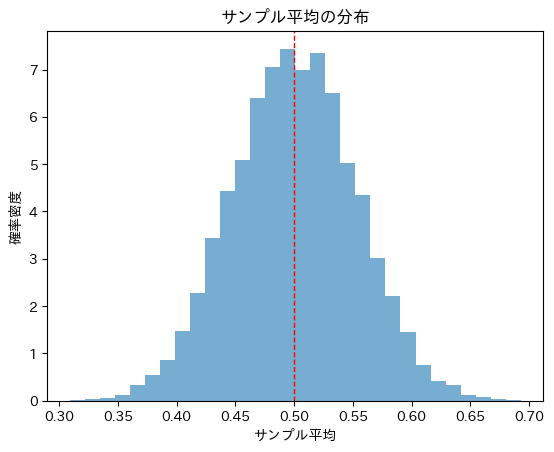

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

n = 30
M = 10000

sample_means = []
for _ in range(M):
    sample = np.random.uniform(low=0.0, high=1.0, size=n)
    mean = np.mean(sample)
    sample_means.append(mean)

sample_means = np.array(sample_means)
plt.hist(sample_means, bins=30, density=True, alpha=0.6)
plt.title('サンプル平均の分布')
plt.xlabel('サンプル平均')
plt.ylabel('確率密度')
plt.axvline(x=0.5, color='r', linestyle='dashed', linewidth=1)
plt.show()

### 問4

問3で得られた $M=10000$ 個のサンプル平均の分布をプロットして、どのような関数形になっているかを考察しなさい。

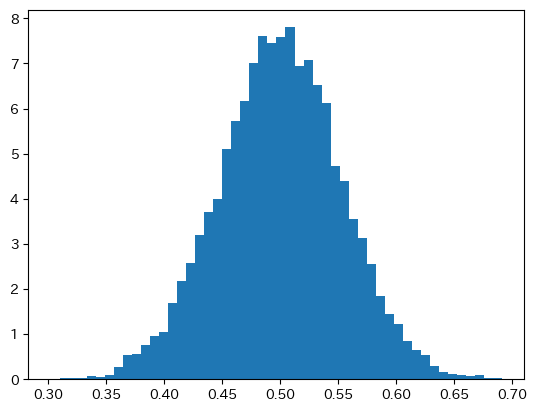

In [78]:
import matplotlib.pyplot as plt
import numpy as np

n = 30
M = 10000

sample_means = []
for _ in range(10000):
    sample = np.random.uniform(low=0.0, high=1.0, size=n)
    mean = np.mean(sample)
    sample_means.append(mean)

sample_means = np.array(sample_means)

plt.hist(sample_means, bins=50, density=True)
plt.show()

### 問5

時間が余れば、Pythonで確率分布を扱うことに慣れるために、下記のドキュメントを見ておいてください。ニューラルネットの勉強だけでなく、データサイエンス分野で役に立ちます。

[https://docs.scipy.org/doc/scipy/tutorial/stats/probability_distributions.html](https://docs.scipy.org/doc/scipy/tutorial/stats/probability_distributions.html)

確率論
- 確率変数
- 確率分布
- 期待値 / 平均値
- 分散
- 大数の法則
- 中心極限定理

## 第3回

### 問1

関数 $f(x) = 3x + 2$ について、関数値と微分係数をひとつのグラフにプロットしなさい。ただし、微分はPyTorchの自動微分を使いなさい。

### 問2

関数 $f(x) = x^2 - 4x + 5$ について、関数値と微分係数をひとつのグラフにプロットしなさい。ただし、微分はPyTorchの自動微分を使いなさい。

### 問3

関数 $f(x, y) =  x^3 + 2xy^2 - y^4 + 5$ について、$x=1, y=2$ の関数値と偏微分係数をそれぞれ計算しなさい。ただし、微分はPyTorchの自動微分を使いなさい。

### 問4

関数 $f(x) = x^4 - 6x^2 + 5$ には複数の極小値が存在する。ニュートン法や勾配降下法を使って、極小値を見つけなさい。

## 第4回

### 参考

In [ ]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
import cv2

In [ ]:
img = torch.zeros(128, 128)
img[50:80, 60:90] = 1.0



def transform_with_affine(img_hw, angle=30, tx=10, ty=5):
    if img_hw.ndim != 2:
        raise ValueError("Error")

    img_chw = img_hw.unsqueeze(0)

    transformed = F.affine(
        img_chw,       
        angle=angle,      
        translate=[tx, ty],    
        scale=1.0,              
        shear=[0.0, 0.0],      
    )

    return transformed.squeeze(0)

img = torch.zeros(128, 128)
img[50:80, 60:90] = 1.0

transformed = transform_with_affine(img, angle=45, tx=20, ty=-10)

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap='gray')


In [ ]:
def transform_numpy(img: np.ndarray, angle: float, x_shift: float, y_shift: float) -> np.ndarray:

    h, w = img.shape
    center = (w / 2, h / 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotation_matrix[0, 2] += x_shift
    rotation_matrix[1, 2] += y_shift

    transformed = cv2.warpAffine(img, rotation_matrix, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    return transformed



img = np.zeros((128, 128), dtype=np.uint8)
img[40:80, 50:90] = 255

transformed = transform_numpy(img, angle=30, x_shift=20, y_shift=10)

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap='gray')

以下の問を、numpy と PyTorch それぞれで答えなさい。

### 問1

$x= (2, 1)$ の点を、原点を中心に60度だけ左に回転しなさい。

### 問2

$x= (2, 1)$ の点を、原点から左に $4$, 上に $3$ だけ移動しなさい。

### 問3

$x= (2, 1)$ の点を、原点から10倍離れた点に移動しなさい。

### 発展

手持ちの画像データに対して、アフィン変換を行いなさい。

## 第6回

次のデータセットについて、線形回帰を行う。入力は `study_hours` , 出力は `score` とする。

In [80]:
data = [
    {"study_hours": 1, "score": 55},
    {"study_hours": 2, "score": 60},
    {"study_hours": 3, "score": 65},
    {"study_hours": 4, "score": 70},
    {"study_hours": 5, "score": 75},
    {"study_hours": 6, "score": 80},
    {"study_hours": 7, "score": 85},
    {"study_hours": 8, "score": 90},
    {"study_hours": 9, "score": 95},
    {"study_hours": 10, "score": 100},
]

### 問1

`data` がどのようなものか、プロットなどして確認しなさい。

### 問2

ここでは、`scikit-learn`ライブラリに実装されている`LinearRegression`クラスを使って、線形回帰モデルを構築し、学習を行いなさい。

### 問3

`scikit-learn`ライブラリを使わずに、自分で線形回帰モデルを定義して、誤差関数を定めなさい。パラメータの最適化にはライブラリを使ってよい。

### 問4

問3で用いた Optimizer以外で学習しなさい。

### 発展

PyTorchを使って、上記の線形回帰を実装しなさい。